Data

In [104]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from Bio import SeqIO
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')
os.chdir('/Users/houlin/Desktop/Ecohab/Ecohab22/metatranscriptoms')
path=os.getcwd()

Functions


In [159]:

def normalize_rows(data):
    colnames = data.columns.tolist()
    rownames = data.index.tolist()
    normalized_data = np.zeros_like(data, dtype=float)
    num_rows, num_cols = data.shape
    for i in range(num_rows):
        normalized_data[i] = (data.iloc[i] - np.min(data.iloc[i])) / (np.max(data.iloc[i])-np.min(data.iloc[i]))
    normalized_data=pd.DataFrame(normalized_data)
    normalized_data.columns=colnames
    normalized_data.index=rownames
    return normalized_data

def rank_by_mean(df):
    df_ranked = df.loc[df.mean(axis=1).sort_values(ascending=False).index]
    return df_ranked
def genename_df(df,genus):
# genus is False-> all, or specify the genus
    if not genus:
        df=df
    else:
        df=df.dropna(subset=['LPI_taxonomy'])
        df=df[df.LPI_taxonomy.str.contains(genus)]
    df_dab = df.dropna(subset=['dab_gene'])
    df_dab=df_dab.set_index('dab_gene').iloc[:,3:66]
    df_dab_sum=df_dab.groupby(df_dab.index).sum()
    df_ISIP = df.dropna(subset=['ISIP_gene'])
    df_ISIP=df_ISIP.set_index('ISIP_gene').iloc[:,3:66]
    df_ISIP_sum=df_ISIP.groupby(df_ISIP.index).sum()
    df_nitrogen = df.dropna(subset=['N_genes'])
    df_nitrogen=df_nitrogen.set_index('N_genes').iloc[:,3:66]
    df_nitrogen_sum=df_nitrogen.groupby(df_nitrogen.index).sum()
    df_filter=df.dropna(subset=['Pfam_description'])
    #df_filter=df_filter[~df_filter.Pfam_description.str.contains('Ribosomal',case=False)]
    df_filter=df_filter[~df_filter.Pfam_description.str.contains('unknown',case=False)]
    df_pfam=df_filter.set_index('Pfam_description').iloc[:,3:66]
    df_pfam_sum=df_pfam.groupby(df_pfam.index).sum()
    df_sum= pd.concat([df_dab_sum, df_ISIP_sum,df_nitrogen_sum,df_pfam_sum], axis=0, ignore_index=False)
    df_sum=rank_by_mean(df_sum)
    return df_sum
def count_tax(filtered_gene_df):
    #df_l7=gene_df.set_index('L7')
    #df_l7=df_l7.iloc[:,3:66] filtering the dataframe to keep only the samples, not NC or PC
    a=pd.DataFrame(filtered_gene_df.sum(axis=1))
    a=a.groupby(a.index).sum()
    totalcount=a.sum()[0]
    a.columns=['counts']
    percent=[x/totalcount for x in a.counts]
    a['percent']=percent

    a.reset_index(drop=False, inplace=True)
    a.columns = ['tax', 'counts', 'percent']
    sorted_a=a.sort_values(by='counts',ascending=False)
    return sorted_a

def calculate_percentage(df):
    # Calculate the sum of each column, axis=0 is column
    column_sums = df.sum(axis=0) 
    # Divide each element by its column sum and multiply by 100 to get percentage
    percentages_df = df.div(column_sums, axis=1) 

    return percentages_df

def averaging_expression(expression,metadata_used):
    df_mean=expression
    if metadata_used in ['Date','sample-id','group_chl']:
        df_mean.columns=metadata[metadata_used]
    else:
        df_mean.columns=round(metadata[metadata_used],1)
    df_mean=df_mean.sort_index(axis=1)
    df_T = df_mean.T
    # Group by the index (original column names) and sum
    df_grouped = df_T.groupby(df_T.index).mean()
    # Transpose back to the original orientation
    df_mean = df_grouped.T
    df_mean_normalized=normalize_rows(df_mean)
    return df_mean, df_mean_normalized

import plotly.graph_objects as go


def generate_colors(num_shades,color):
    """
    Parameters:
    - num_shades (int): The number of cold colors to generate.
    Returns:
    - list: A list of RGBA color strings.
    """
    shades = []
    for i in range(num_shades):
        intensity = (i + 1) / num_shades
        if color=='cold':
            red = 0
            green = int(255 * intensity)
            blue = int(255)
        elif color=='warm':
            red = int(255)
            green = int(128 + (127 * intensity))  # Vary green to create shades
            blue = 0
        shades.append(f'rgba({red}, {green}, {blue}, 0.8)') 
    return shades


In [458]:
metadata=pd.read_csv('/Users/houlin/Desktop/Ecohab/Ecohab22/data/Ecohab22_metadata_082324.csv')
#metadata=metadata[0:65]
metadata=metadata.sort_values(by='sample-id')
metadata1=metadata
metadata= metadata[~metadata['sample-id'].isin(['EH16_0070','EH15_0064'])] # the lack of EH15 and EH16
metadata['group_chl'] = pd.cut(metadata['Mean_Chl'], 
                         bins=[0, 1, 2, 3,4,5,6,7,8,9,11], 
                         labels=['0-1', '1-2', '2-3','3-4','4-5','5-6','6-7','7-8','8-9','11'], 
                         right=False)

In [386]:
df_tax_full=pd.read_csv('Ecohab22_meta_taxfull_070524.csv')
cpl_tax_fll=pd.read_csv('cpl_filtered_tax_full_081924.csv')
cpl_tax_fll.rename(columns={
    'Domain': 'L1',
    'Kingdom': 'L2',
    'Phylum': 'L3',
    'Class': 'L4',
    'Order': 'L5',
    'Family': 'L6',
    'Genus': 'L7',
    'Species': 'L8'
}, inplace=True)


Data Amplicons

In [9]:
df=pd.read_csv('/Users/houlin/Desktop/Ecohab/Ecohab22/Amplicons/sequence_results/Ecohab_taxonomy_18S_16S.csv')
tax18s_Eu=df[df.L1=='Eukaryota']
tax16s_Pro=df[df.L1!='Eukaryota']

In [10]:
#class 116-->filter class 103
tax18s_Eu['L5_filter'] = tax18s_Eu['L5'].str.split('_').str[0]
tax18s_L5=tax18s_Eu.set_index('L5_filter')
tax18s_L5=tax18s_L5.iloc[:,1:64]
tax18s_L5_sum=tax18s_L5.groupby(tax18s_L5.index).sum()

#family 431
tax18s_L7=tax18s_Eu.set_index('L7')
tax18s_L7=tax18s_L7.iloc[:,1:64]
tax18s_L7_sum=tax18s_L7.groupby(tax18s_L7.index).sum()


In [11]:

tax_l7=count_tax(df_18s_Eu.L7)
tax_l7.loc[tax_l7['percent']<0.01,'tax']='others'
tax_l7_eu=tax_l7.groupby(tax_l7.tax).sum()

tax_l5=count_tax(df_18s_Eu.L5_filter)
tax_l5.loc[tax_l5['percent']<0.01,'tax']='others'
tax_l4=tax_l5.groupby(tax_l5.tax).sum()

ValueError: No axis named 1 for object type Series

In [4]:
ISIP_df = df_tax_full.dropna(subset=['ISIP_gene'])
nitrogen_df = df_tax_full.dropna(subset=['N_genes'])

In [100]:
df=cpl_tax_fll
ISIP_df = df.dropna(subset=['ISIP_gene'])
nitrogen_df = df.dropna(subset=['N_genes'])



In [ ]:
central_carbon=['Fructose-1-6-bisphosphatase, N-terminal domain','Fructose-1-6-bisphosphatase, C-terminal domain',
                'Fructose-bisphosphate aldolase class-I','Fructose-bisphosphate aldolase class-II','NAD-dependent glycerol-3-phosphate dehydrogenase N-terminus',
                 'NAD-dependent glycerol-3-phosphate dehydrogenase C-terminus','Phosphoenolpyruvate carboxylase','Glyceraldehyde 3-phosphate dehydrogenase, C-terminal domain',
                 'Glyceraldehyde 3-phosphate dehydrogenase, NAD binding domain']

glycerolipid=['Inositol phosphatase']

In [399]:
df=df.dropna(subset='Pfam_description')
a=df[df.Pfam_description.str.contains('urease',case=False)]
print(set(a.Pfam_description))
a

{'Urease beta subunit', 'Urease alpha-subunit, N-terminal domain', 'UreD urease accessory protein', 'Urease, gamma subunit'}


,geneID,start,end,length,EH10_0126,EH11_0213,EH12_0110,EH13_0269,EH14_0151,EH17_0232,...,L2,L3,L4,L5,L6,L7,L8,dab_gene,N_genes,ISIP_gene
17287,contig5370982_1_891_+,1,891,891,1.111158e+05,3.879938e+05,0.000000e+00,1.330844e+04,1.089103e+06,0.000000e+00,...,Archaeplastida,Chlorophyta,Mamiellophyceae,Mamiellales,Mamiellaceae,Micromonas,Micromonas sp. CCMP1646,NaN,NaN,NaN
72351,contig5317651_2460_3914_-,1,1455,1455,2.098854e+05,1.804623e+04,0.000000e+00,6.654219e+04,1.530145e+05,0.000000e+00,...,Archaeplastida,Chlorophyta,Mamiellophyceae,Mamiellales,Mamiellaceae,Micromonas,Micromonas pusilla CCAC1681,NaN,NaN,NaN
81977,contig87664_3_1067_-,1,1065,1065,5.271826e+06,2.048247e+06,0.000000e+00,2.661688e+04,0.000000e+00,4.725105e+04,...,Hacrobia,Haptophyta,Prymnesiophyceae,Phaeocystales,Phaeocystaceae,Phaeocystis,Phaeocystis antarctica Caron Lab,NaN,NaN,NaN
124272,contig1567406_2_751_-,1,750,750,1.605006e+05,0.000000e+00,0.000000e+00,1.397386e+05,3.780358e+05,0.000000e+00,...,Archaeplastida,Chlorophyta,Mamiellophyceae,Mamiellales,Bathycoccaceae,Ostreococcus,Ostreococcus lucimarinus clade-A-BCC118000,NaN,NaN,NaN
171267,contig2821424_3_623_-,1,621,621,9.259648e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,Alveolata,Dinophyta,Dinophyceae,Dinophyceae_X,Dinophyceae_XX,Prorocentrum,Prorocentrum minimum CCMP1329,NaN,NaN,NaN
201694,contig2112900_3_413_+,1,411,411,2.469239e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.450210e+04,...,Archaeplastida,Chlorophyta,Mamiellophyceae,Mamiellales,Bathycoccaceae,Ostreococcus,Ostreococcus lucimarinus clade-A-BCC118000,NaN,NaN,NaN
224100,contig12723_132_1169_-,1,1038,1038,4.673036e+06,3.275390e+06,9.536463e+05,3.240605e+06,3.960375e+05,3.543829e+04,...,Archaeplastida,Chlorophyta,Mamiellophyceae,Mamiellales,Bathycoccaceae,Bathycoccus,Bathycoccus prasinos BCC99000,NaN,NaN,NaN
285617,contig5896053_1461_3338_-,1,1878,1878,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,Stramenopiles,Stramenopiles_X,Bacillariophyta,Bacillariophyta_X,Raphid-pennate,Pseudo-nitzschia,Pseudo-nitzschia pungens,NaN,NaN,NaN
294050,contig5392674_2272_3498_+,1,1227,1227,8.148490e+05,5.955254e+05,0.000000e+00,0.000000e+00,4.500426e+05,0.000000e+00,...,Archaeplastida,Chlorophyta,Mamiellophyceae,Mamiellales,Mamiellaceae,Micromonas,Micromonas sp. RCC451,NaN,NaN,NaN
306263,contig2060565_1_519_-,1,519,519,7.407718e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.450210e+04,...,Stramenopiles,Stramenopiles_X,Bacillariophyta,Bacillariophyta_X,Polar-centric-Mediophyceae,Chaetoceros,"Chaetoceros , Strain UNC1202",NaN,NaN,NaN


In [18]:
ngene=['GSIIA','GSIIB','GSIIC','GSIII','NR','NRT2','NirB','NirG']
ngene_df_list={}
N_genes={}
for gene in ngene:
    gene_df=nitrogen_df[nitrogen_df['N_genes']==gene]
    N_genes[gene]=gene_df
    df_l7=gene_df.set_index('L7')
    df_l7=df_l7.iloc[:,3:66]
    tax_l7=count_tax(df_l7)
    tax_l7.loc[tax_l7['percent']<0.01,'tax']='others'
    tax_l7=tax_l7.groupby(tax_l7.tax).sum()
    ngene_df_list[gene+'_tax_L7']=tax_l7
    
    df_l4=gene_df.set_index('L4')
    df_l4=df_l4.iloc[:,3:66]
    tax_l4=count_tax(df_l4)
    tax_l4.loc[tax_l4['percent']<0.01,'tax']='others'
    tax_l4=tax_l4.groupby(tax_l4.tax).sum()
    ngene_df_list[gene+'_tax_L4']=tax_l4


isip_gene=['ISIP1','ISIP2A','ISIP2B']
ISIP_df_list={}
ISIP_genes={}
for gene in isip_gene:
    gene_df=ISIP_df[ISIP_df['ISIP_gene']==gene]
    ISIP_genes[gene]=gene_df
    df_l7=gene_df.set_index('L7')
    df_l7=df_l7.iloc[:,3:66]
    tax_l7=count_tax(df_l7)
    tax_l7.loc[tax_l7['percent']<0.01,'tax']='others'
    tax_l7=tax_l7.groupby(tax_l7.tax).sum()
    ISIP_df_list[gene+'_tax_L7']=tax_l7
    
    df_l4=gene_df.set_index('L4')
    df_l4=df_l4.iloc[:,3:66]
    tax_l4=count_tax(df_l4)
    tax_l4.loc[tax_l4['percent']<0.01,'tax']='others'
    tax_l4=tax_l4.groupby(tax_l4.tax).sum()
    ISIP_df_list[gene+'_tax_L4']=tax_l4


In [400]:
gene_of_interest=['Chlorophyll A-B binding protein','Flavodoxin','Glutamine synthetase, catalytic domain',
                  'Silicon transporter','Thioredoxin-like [2Fe-2S] ferredoxin']

urea_cycle=['Ornithine cyclodeaminase/mu-crystallin family','Ornithine decarboxylase antizyme',
            'Aspartate/ornithine carbamoyltransferase, carbamoyl-P binding domain',
            'Urea transporter','Arginase family','Argininosuccinate lyase C-terminal',
            'Urease beta subunit', 'Urease alpha-subunit, N-terminal domain', 'UreD urease accessory protein', 
            'Urease, gamma subunit']

#glutamine synthetase, glutamate synthase (GOGAT)
ammoninum_assimilation=['Glutamine synthetase type III N terminal', 'Ammonium Transporter Family','Glutamine synthetase, beta-Grasp domain', 'Glutamine synthetase, catalytic domain', 'Glutamine synthetase C-terminal domain',
                        'Glutamate/Leucine/Phenylalanine/Valine dehydrogenase','NAD-specific glutamate dehydrogenase','Glutamate synthase central domain','Conserved region in glutamate synthase']
df_list={}
genes_df={}
for gene in ammoninum_assimilation:
    gene_df=cpl_tax_fll[cpl_tax_fll['Pfam_description']==gene]
    genes_df[gene]=gene_df
    df_l7=gene_df.set_index('L7')
    df_l7=df_l7.iloc[:,3:66]
    tax_l7=count_tax(df_l7)
    tax_l7.loc[tax_l7['percent']<0.01,'tax']='others'
    tax_l7=tax_l7.groupby(tax_l7.tax).sum()
    df_list[gene+'_tax_L7']=tax_l7
    
    df_l4=gene_df.set_index('L4')
    df_l4=df_l4.iloc[:,3:66]
    tax_l4=count_tax(df_l4)
    tax_l4.loc[tax_l4['percent']<0.01,'tax']='others'
    tax_l4=tax_l4.groupby(tax_l4.tax).sum()
    df_list[gene+'_tax_L4']=tax_l4

In [51]:
#gene_df=nitrogen_df[nitrogen_df['N_genes']==gene]

#gene_df=tax18s_Eu
gene_df=cpl_tax_fll

df_l7=gene_df.set_index('L7').iloc[:,3:66]
tax_l7=count_tax(df_l7)
tax_l7.loc[tax_l7['percent']<0.01,'tax']='others'
tax_l7=tax_l7.groupby(tax_l7.tax).sum()

df_l4=gene_df.set_index('L4').iloc[:,3:66]
tax_l4=count_tax(df_l4)
tax_l4.loc[tax_l4['percent']<0.01,'tax']='others'
tax_l4=tax_l4.groupby(tax_l4.tax).sum()



Sankey 
1. isip_gene=['ISIP1','ISIP2A','ISIP2B']
2. ngene=['GSIIA','GSIIB','GSIIC','GSIII','NR','NRT2','NirB','NirG']
3. gene_of_interest=['Chlorophyll A-B binding protein','Flavodoxin','Glutamine synthetase, catalytic        domain', 'Silicon transporter','Thioredoxin-like [2Fe-2S] ferredoxin']
4. urea_cycle=['Ornithine cyclodeaminase/mu-crystallin family','Ornithine decarboxylase antizyme','Aspartate/ornithine carbamoyltransferase, carbamoyl-P binding domain','UreD urease accessory protein','Urea transporter','Arginase family','Argininosuccinate lyase C-terminal']
5. ammoninum_assimilation=['Glutamine synthetase type III N terminal', 'Glutamine synthetase, beta-Grasp domain', 'Glutamine synthetase, catalytic domain', 'Glutamine synthetase C-terminal domain','Glutamate/Leucine/Phenylalanine/Valine dehydrogenase','NAD-specific glutamate dehydrogenase','Glutamate synthase central domain','Conserved region in glutamate synthase']

In [134]:
# diatom (Glutamine synthetase type III N terminal,Glutamine synthetase, catalytic domain,
# Glutamate/Leucine/Phenylalanine/Valine dehydrogenase,Glutamate synthase central domain)
genename='Conserved region in glutamate synthase'

if genename in isip_gene:
    data=ISIP_genes[genename]
    l4=ISIP_df_list[genename+'_tax_L4']
    l7=ISIP_df_list[genename+'_tax_L7']
elif genename in ngene:
    data=N_genes[genename]
    l4=ngene_df_list[genename+'_tax_L4']
    l7=ngene_df_list[genename+'_tax_L7']
elif genename in ammoninum_assimilation:
    data=genes_df[genename]
    l4=df_list[genename+'_tax_L4']
    l7=df_list[genename+'_tax_L7']


#data=gene_df
# l4=tax_l4
# l7=tax_l7
#create the sankey label, sources and targets for each nodes
create_sankey_diagrame(data,l4,l7)

In [130]:
def create_sankey_diagrame(data,l4,l7):
    sankey_df={genename:l4.counts.sum()}
    orders=list(l4.index)
    sources,targets=[],[]
    for i in range(len(orders)):
        order=orders[i]

        sources.append(0) #all the order will be connected to the total gene samples
        order_num=len(sankey_df) # define the index of the label for the orders
        targets.append(order_num)
        
        order_count=l4.loc[l4.index==order,'counts'][0] # find the total counts of the orders
        order_percent=round(l4.loc[l4.index==order,'percent'][0]*100)
        sankey_df[order+' '+str(order_percent)+'%']=order_count # add the order to the dictionary
        if order!='others':
            order_df=data.loc[data.L4==order,'L7']
            # Identifying species in each order and add them to the dictionary
            species=list(set(order_df))
            total=0
            species_count,species_exist=[],[]
            for sp in species:
                if sp in list(l7.index):
                    species_exist.append(sp)
                    total+=l7.loc[l7.index==sp,'counts'][0]
                    species_count.append(l7.loc[l7.index==sp,'counts'][0])
            other_count=order_count-total
            species_exist.append('other '+order)
            species_count.append(other_count)
            
            for j in range(len(species_exist)):
                sources.append(order_num)
                targets.append(len(sankey_df))
                sankey_df[species_exist[j]]=species_count[j]
                
    # Define labels and values
    labels = list(sankey_df.keys())
    counts=list(sankey_df.values()) # values
    values=counts[1:]
    # Create a Sankey diagram
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=2,  # Padding between nodes
            thickness=10,
            #line=dict(color="black", width=0.5),
            label=labels,
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values
        )
    )])

    fig.update_layout(
        hovermode='x',
        #paper_bgcolor='#51504f',
        width=800,
        height=800,
        margin={'t':50,'b':20},
        title_text="Taxa Contribution to "+genename, 
        font_size=12
    )
    # Show the diagram
    fig.show()
    fig.write_image(path+"/plots/cpl_"+genename+"_sankey.svg")


Test

In [416]:
photosynthesis=['Chlorophyll A-B binding protein','Photosynthetic reaction centre protein',
 'Oxidoreductase NAD-binding domain','Manganese-stabilising protein / photosystem II polypeptide',
 'Photosystem I psaA/psaB protein','Photosystem II protein','Photosystem II 12 kDa extrinsic protein (PsbU)',
 'ATP synthase','Cytochrome C oxidase, cbb3-type, subunit III',
 'Copper binding proteins, plastocyanin/azurin family']

isip=['ISIP1', 'ISIP2A', 'ISIP2B','Flavodoxin']
nitrogen_gene=['GSIIA', 'GSIIB', 'GSIIC', 'GSIII', 'NR', 'NRT2', 'NirB', 'NirG'] #, diatom doesn't have these

urea_cycle=['Ornithine cyclodeaminase/mu-crystallin family','Ornithine decarboxylase antizyme',
            'Aspartate/ornithine carbamoyltransferase, carbamoyl-P binding domain',
            'Arginase family','Argininosuccinate lyase C-terminal',
            'Urease beta subunit', 'Urease alpha-subunit, N-terminal domain', 'UreD urease accessory protein', 
            'Urease, gamma subunit']

glycerolipid=['Aldo/keto reductase family',
 'Lipase (class 3)',
 'Acyltransferase',
 'Serine aminopeptidase, S33',
 'Glycosyl transferase family group 2',
 'Diacylglycerol acyltransferase',
 'NAD dependent epimerase/dehydratase family',
 'Alpha galactosidase A',
 'Legume lectin domain',
 'Alpha galactosidase C-terminal beta sandwich domain']

glycerolipid_dia=['Serine aminopeptidase, S33',
 'Aldo/keto reductase family',
 'Zinc-binding dehydrogenase',
 'MBOAT, membrane-bound O-acyltransferase family',
 'NAD dependent epimerase/dehydratase family',
 'Lipase (class 3)',
 'WS/DGAT C-terminal domain',
 'Acyltransferase',
 'Diacylglycerol acyltransferase',
 'Patatin-like phospholipase']
#glutamine synthetase, glutamate synthase (GOGAT)
ammoninum_assimilation=['Glutamine synthetase type III N terminal', 'Glutamine synthetase, beta-Grasp domain', 
                         'Glutamine synthetase C-terminal domain','Ammoninum transporter',
                        'Glutamate/Leucine/Phenylalanine/Valine dehydrogenase','NAD-specific glutamate dehydrogenase',
                        'Glutamate synthase central domain','Conserved region in glutamate synthase']

calvin_cycle=['Ribulose bisphosphate carboxylase large chain, catalytic domain',
 'Glyceraldehyde 3-phosphate dehydrogenase, C-terminal domain',
 'Glyceraldehyde 3-phosphate dehydrogenase, NAD binding domain',
 'Phosphoglycerate kinase','Fructose-bisphosphate aldolase class-II','Triosephosphate isomerase',
 'Phosphoribulokinase / Uridine kinase family','Fructose-1-6-bisphosphatase, C-terminal domain',]

26


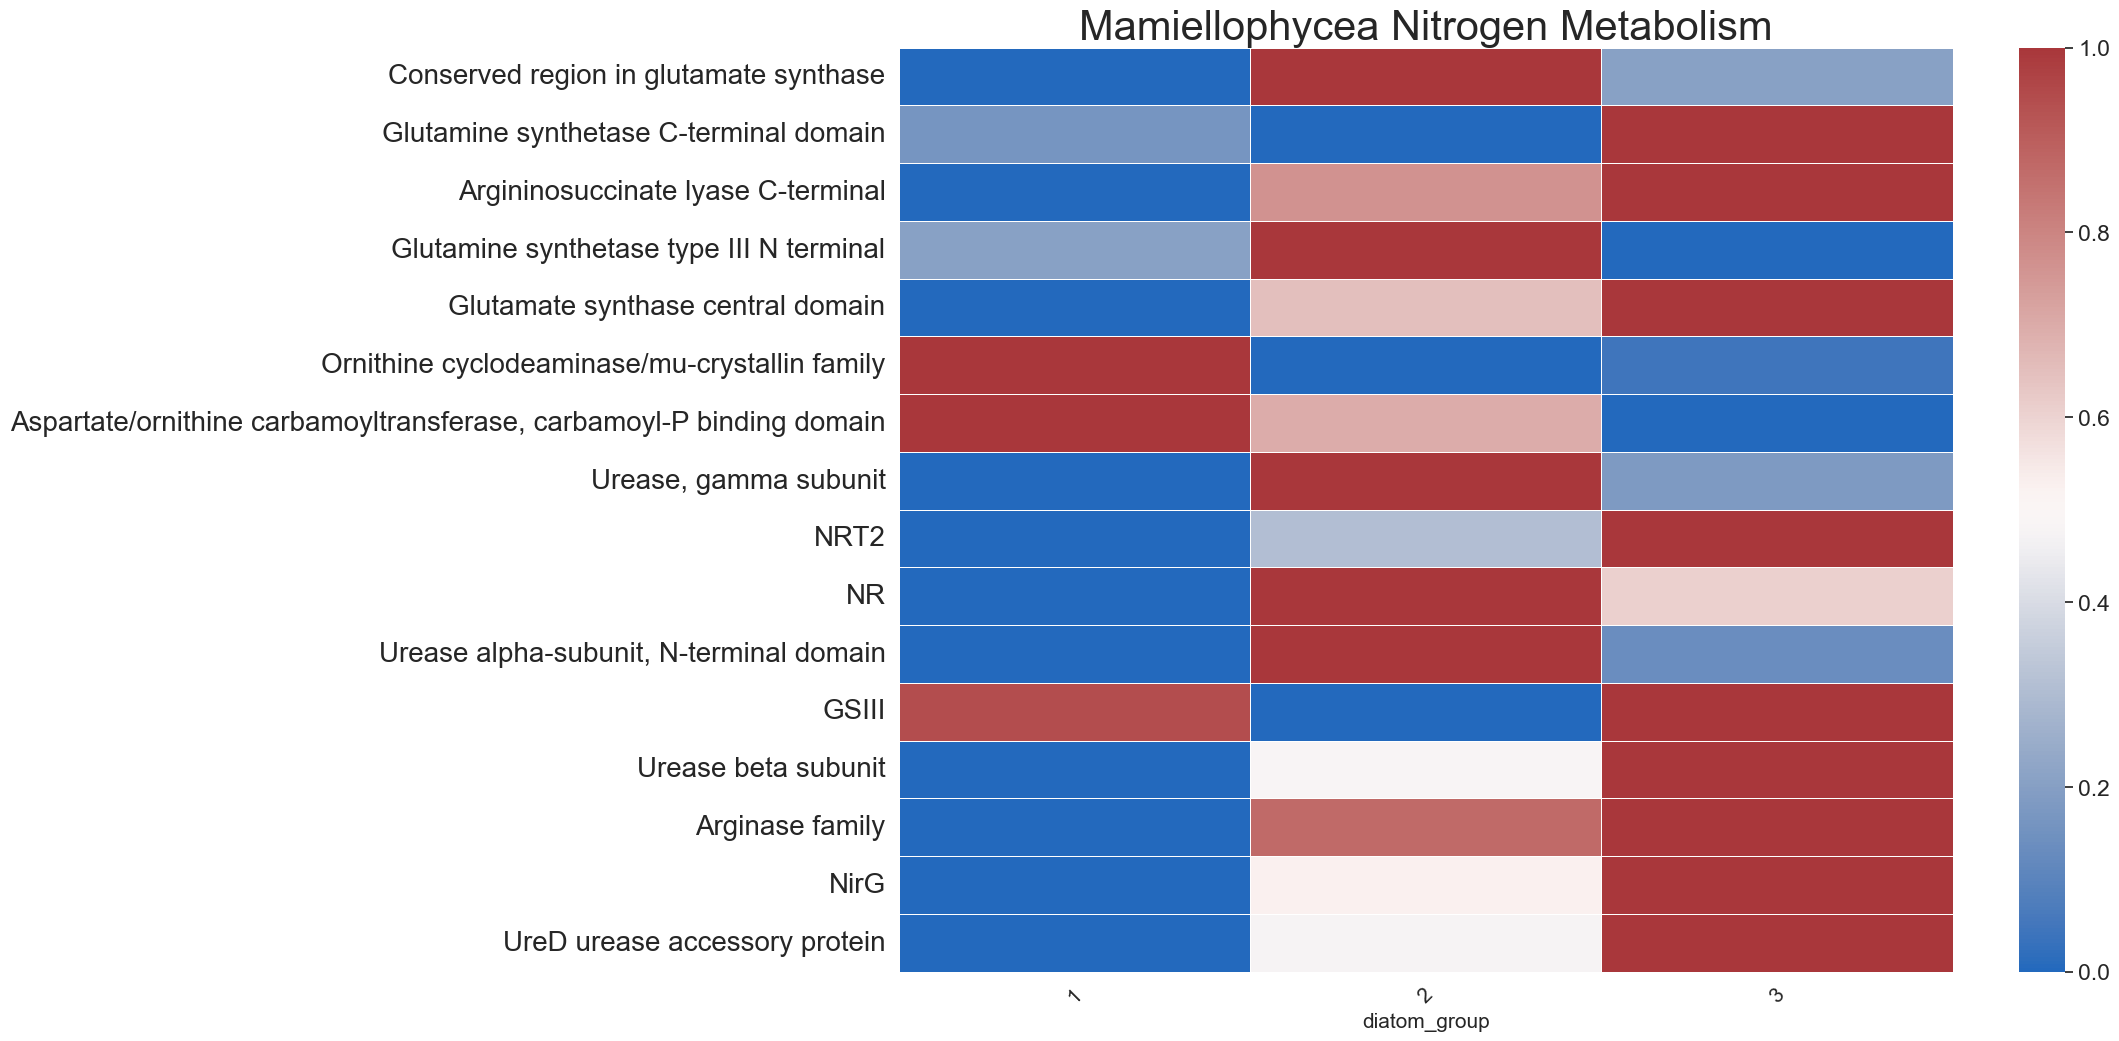

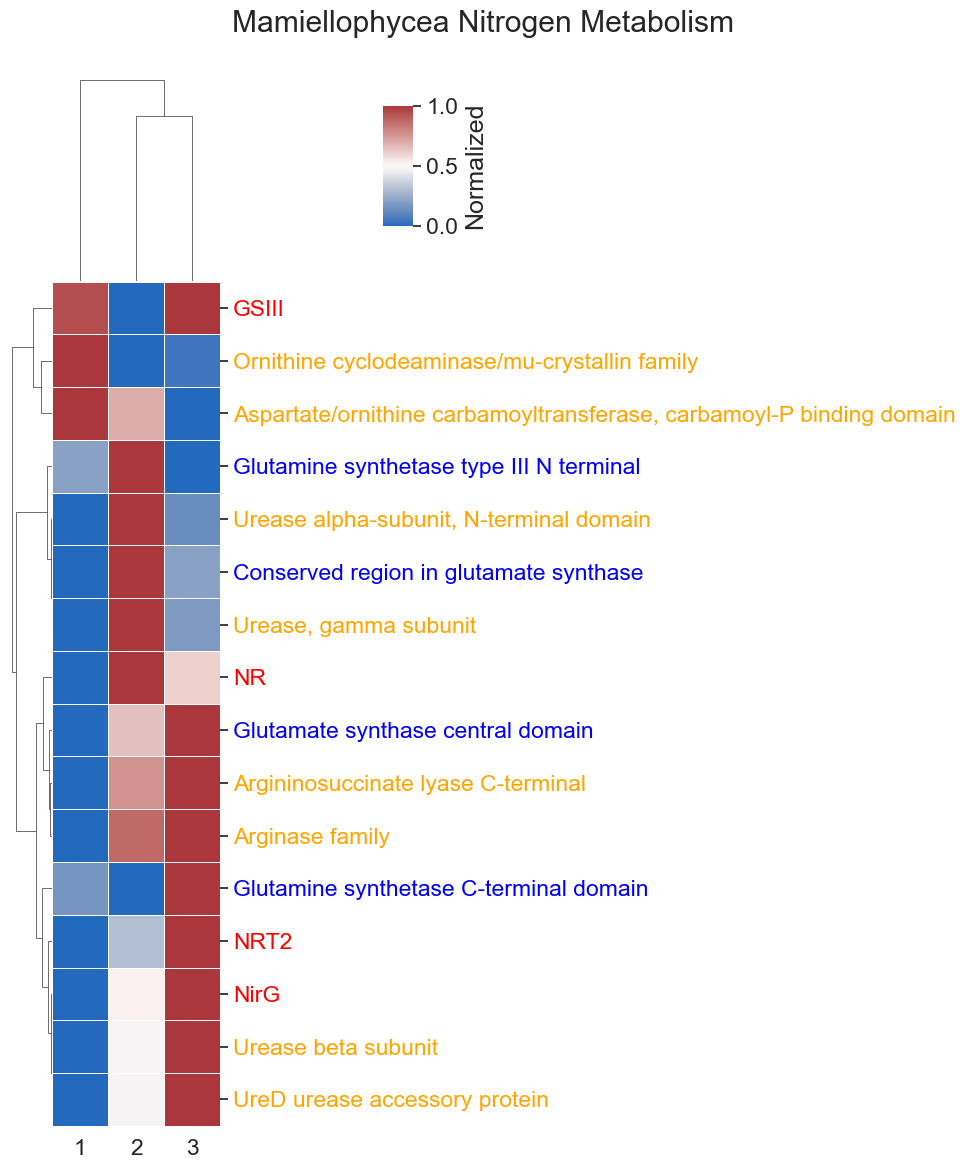

In [451]:
df=cpl_tax_fll
#df.iloc[:,3:66]=calculate_percentage(df.iloc[:,3:66])
tax_name='Mamiellophycea'
cpl_df=genename_df(df,tax_name) #'Bacillariophyta' 'Mamiellophycea'
cpl_df_relative=calculate_percentage(cpl_df)

gene_used=urea_cycle + nitrogen_gene + ammoninum_assimilation
df_used=cpl_df_relative
mask = df_used.index.str.contains('|'.join(gene_used), case=False)

Pfam_filtered = rank_by_mean(df_used[mask])
print(len(Pfam_filtered))

set1=set(Pfam_filtered.index)
set2=set(gene_used)
use=list(set1.intersection(set2))

dataused='diatom_group'
dfv_mean,dfv_norm=averaging_expression(Pfam_filtered.loc[use],dataused)

name=f'{tax_name} Nitrogen Metabolism'
plt.figure(figsize=(17, 12)) 
sns.heatmap(dfv_norm, cmap="vlag", fmt=".1f", linewidths=.5)
plt.title(name,fontsize=30)
plt.xlabel(dataused,fontsize=15)
plt.yticks(fontsize=20)
plt.xticks(fontsize=15,rotation=45)
plt.show()

sns.set_theme(font_scale=1.5)
# Create the heatmap with hierarchical clustering
g=sns.clustermap(dfv_norm, cmap="vlag", method='ward',figsize=(10,12),linewidth=0.5,
                 cbar_kws={'shrink': 0.2, 'label': 'Normalized'})
        
for label in g.ax_heatmap.get_yticklabels():
    x=label.get_text()
    if x in nitrogen_gene:
        label.set_color('red')
    elif x in urea_cycle:
        label.set_color('orange')
    elif x in ammoninum_assimilation:
        label.set_color('blue')

    
g.figure.subplots_adjust(top=0.93)
g.figure.suptitle(name)
g.cax.set_position([0.4, 0.8, 0.03, 0.1]) 

# Display the plot
plt.show()

In [231]:
KO_pathway=pd.read_csv('/Users/houlin/Desktop/Ecohab/Ecohab22/metatranscriptoms/Kegg_pathway/KO_pathway_info.csv')
# metadata['group_chl'] = pd.cut(metadata['Mean_Chl'], 
#                          bins=[0, 1, 2, 3,4,5,6,7,8,9,11], 
#                          labels=['0-1', '1-2', '2-3','3-4','4-5','5-6','6-7','7-8','8-9','11'], 
#                          right=False)


In [284]:
lipid_pathway=KO_pathway[KO_pathway.Level_C.str.contains('Glycerolipid metabolism',case=False)]
K_lipid=lipid_pathway.K_number
df=cpl_tax_fll.dropna(subset='KO')
df=df[df.L4=='Bacillariophyta']
df.iloc[:,3:66]=calculate_percentage(df.iloc[:,3:66])
lipid_df= df[df.KO.str.contains('|'.join(K_lipid), case=False)]
lipid_pfam=lipid_df.set_index('Pfam_description').iloc[:,3:66]
lipid_pfam=rank_by_mean(lipid_pfam.groupby(lipid_pfam.index).sum())
list(lipid_pfam[0:10].index)


In [297]:
carbon_pathway=KO_pathway[KO_pathway.Level_C.str.contains('Carbon fixation by Calvin cycle',case=False)]
K_CalvinCycle=carbon_pathway.K_number
df=cpl_tax_fll.dropna(subset='KO')
df=df[df.L4=='Bacillariophyta']
df.iloc[:,3:66]=calculate_percentage(df.iloc[:,3:66])
carbon_df= df[df.KO.str.contains('|'.join(K_CalvinCycle), case=False)]
carbon_pfam=carbon_df.set_index('Pfam_description').iloc[:,3:66]
carbon_pfam=rank_by_mean(carbon_pfam.groupby(carbon_pfam.index).sum())
list(carbon_pfam[0:10].index)

In [331]:
photosynthesis_pathway=KO_pathway[KO_pathway.Level_C.str.contains('Photosynthesis',case=False)]
K_photo=photosynthesis_pathway.K_number
df=cpl_tax_fll.dropna(subset='KO')
df=df[df.L4=='Bacillariophyta']
df.iloc[:,3:66]=calculate_percentage(df.iloc[:,3:66])
photosynthesis_df= df[df.KO.str.contains('|'.join(K_photo), case=False)]
photosynthesis_pfam=photosynthesis_df.set_index('Pfam_description').iloc[:,3:66]
photosynthesis_pfam=rank_by_mean(photosynthesis_pfam.groupby(photosynthesis_pfam.index).sum())
list(photosynthesis_pfam[0:10].index)

['Chlorophyll A-B binding protein',
 'Photosynthetic reaction centre protein',
 'Oxidoreductase NAD-binding domain',
 'Manganese-stabilising protein / photosystem II polypeptide',
 'Photosystem I psaA/psaB protein',
 'Photosystem II protein',
 'Photosystem II 12 kDa extrinsic protein (PsbU)',
 'ATP synthase',
 'Cytochrome C oxidase, cbb3-type, subunit III',
 'Copper binding proteins, plastocyanin/azurin family']

In [333]:
nitrogen_pathway=KO_pathway[KO_pathway.Level_C.str.contains('Nitrogen metabolism',case=False)]
K_N=nitrogen_pathway.K_number
df=cpl_tax_fll.dropna(subset='KO')
df=df[df.L4=='Bacillariophyta']
df.iloc[:,3:66]=calculate_percentage(df.iloc[:,3:66])
N_df= df[df.KO.str.contains('|'.join(K_N), case=False)]
N_pfam=N_df.set_index('Pfam_description').iloc[:,3:66]
N_pfam=rank_by_mean(N_pfam.groupby(N_pfam.index).sum())
list(N_pfam[0:10].index)

['KOW motif',
 'Rieske-like [2Fe-2S] domain',
 'Prismane/CO dehydrogenase family',
 'Major Facilitator Superfamily',
 'Glutamine synthetase, catalytic domain',
 'Conserved region in glutamate synthase',
 'Pyridine nucleotide-disulphide oxidoreductase',
 'GXGXG motif',
 'Glutamine synthetase C-terminal domain',
 'Glutamine synthetase type III N terminal']

In [ ]:
{'Carbon fixation by Calvin cycle',
 'Methane metabolism',
 'Nitrogen metabolism',
 'Other carbon fixation pathways',
 'Oxidative phosphorylation',
 'Photosynthesis',
 'Photosynthesis - antenna proteins',
 'Sulfur metabolism'}

In [452]:
from scipy.stats import spearmanr
def spearman_corr_pvalues(df):
    df = df.dropna()._get_numeric_data()
    
    rho = pd.DataFrame(np.zeros((df.shape[1], df.shape[1])),
                       columns=df.columns, index=df.columns)
    pval = pd.DataFrame(np.ones((df.shape[1], df.shape[1])),
                        columns=df.columns, index=df.columns)
    for col in df.columns:
        for row in df.columns:
            if col != row:
                rho[col][row], pval[col][row] = spearmanr(df[col], df[row])
            else:
                rho[col][row] = 1.0
                pval[col][row] = np.nan  # For the same variables, we set NaN
    return rho, pval

In [454]:
df=cpl_tax_fll
cpl_genename_sum_diatom=genename_df(df,'Bacillariophyta')
cpl_rho_diatom,cpl_pval_diatom=spearman_corr_pvalues(cpl_genename_sum_diatom.T)



cpl_genename_sum_PN=genename_df(df,'Pseudo-nitzschia')
cpl_rho_PN,cpl_pval_PN=spearman_corr_pvalues(cpl_genename_sum_PN.T)



In [456]:
cpl_rho_diatom.to_csv('Pfam_gene_corr/cpl_rho_diatom.csv',index=True)
cpl_pval_diatom.to_csv('Pfam_gene_corr/cpl_pval_diatom.csv',index=True)
cpl_rho_PN.to_csv('Pfam_gene_corr/cpl_rho_PN.csv',index=True)
cpl_pval_PN.to_csv('Pfam_gene_corr/cpl_pval_PN.csv',index=True)